# ATF DR RFTrack correction validation

Input: `ATF_DR_20111111b_RFTrack_twiss.tfs`, an all-element RFTrack lattice
generated from the 20111111b SAD daihon. Unlike the legacy target-optics
`ATF_DR_twiss_file.tws`, it is read directly as an RFTrack lattice.

This notebook starts with a one-turn periodic orbit, builds response matrices,
applies COD / dispersion / skew corrections, and then evaluates the radiation
equilibrium represented by repeated turns.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import RF_Track as rft

# Locate flight-simulator from the notebook working directory.
REPOSITORY_ROOT = Path.cwd().resolve()
while not (REPOSITORY_ROOT / "Interfaces").is_dir():
    if REPOSITORY_ROOT.parent == REPOSITORY_ROOT:
        raise RuntimeError("Run this notebook inside flight-simulator.")
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

# Keep the SAD provenance and the directly read correction lattice explicit.
SAD_DAIHON = REPOSITORY_ROOT.parent / "sad/operation/daihon/atfdr-design-20111111b.sad"
TWISS_TFS = REPOSITORY_ROOT / "Interfaces/ATF2/DR_ATF2/ATF_DR_20111111b_RFTrack_twiss.tfs"
LATTICE_JSON = REPOSITORY_ROOT / "Interfaces/ATF2/DR_ATF2/ATF_DR_RFTrack_lattice.json"

from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_correction import ATFDRRingCorrection
from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_lattice import build_atf_dr_lattice
from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_emittance import (
    build_equilibrium_lattice,
    emittance_from_native_covariance,
    equilibrium_emittance_for_lattices,
    gaussian_bunch,
    track_emittance,
)
from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_state import (
    apply_known_machine_state,
    capture_known_machine_state,
    read_known_machine_state,
)

ANALYSIS_DIR = REPOSITORY_ROOT.parent / "analysis/DR-RFTrack"

print("SAD daihon:", SAD_DAIHON)
print("RFTrack Twiss/TFS lattice:", TWISS_TFS)
print("RFTrack JSON used only for the radiation model:", LATTICE_JSON)
assert SAD_DAIHON.exists() and TWISS_TFS.exists() and LATTICE_JSON.exists()


def load_correction_ring():
    # Load the nominal one-turn correction lattice directly from TFS.
    return rft.Lattice(str(TWISS_TFS))



RF-Track, version 2.6.3

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx

SAD daihon: /home/motokisato/Projects/sad/operation/daihon/atfdr-design-20111111b.sad
RFTrack Twiss/TFS lattice: /home/motokisato/Projects/flight-simulator/Interfaces/ATF2/DR_ATF2/ATF_DR_20111111b_RFTrack_twiss.tfs
RFTrack JSON used only for the radiation model: /home/motokisato/Projects/flight-simulator/Interfaces/ATF2/DR_ATF2/ATF_DR_RFTrack_lattice.json


[RF-Track] Could not check for updates.


## 1. One turn: build the ring and find its periodic orbit

`find_closed_orbit()` repeatedly tracks **one turn** and solves
\(f(z)-z=0\). It does not perform long-term multi-turn tracking.


In [2]:
one_turn_lattice = load_correction_ring()
one_turn = ATFDRRingCorrection(one_turn_lattice)
orbit = one_turn.find_closed_orbit()
dispersion = one_turn.measure_dispersion(relative_momentum_step=3.5e-3)

print(f"circumference = {one_turn_lattice.get_length():.6f} m")
print(f"BPMs = {len(orbit.bpm_names)}")
print("closed-orbit initial coordinates [mm, mrad] =", orbit.initial_coordinates)
print("RMS Dx, Dy [mm/delta] =", np.sqrt(np.mean(dispersion.x**2)), np.sqrt(np.mean(dispersion.y**2)))


circumference = 138.559539 m
BPMs = 98
closed-orbit initial coordinates [mm, mrad] = [0. 0. 0. 0.]
RMS Dx, Dy [mm/delta] = 91.92063419263688 0.0


## 2. COD correction from a one-turn response matrix

The nominal lattice is the correction model. A separate lattice is the virtual
machine and contains an unregistered kick. The response is \(R_{ij}=\partial x_i/\partial\theta_j\).


SVD rank = 6
COD RMS: 4.3824e-01 -> 3.1622e-02 mm


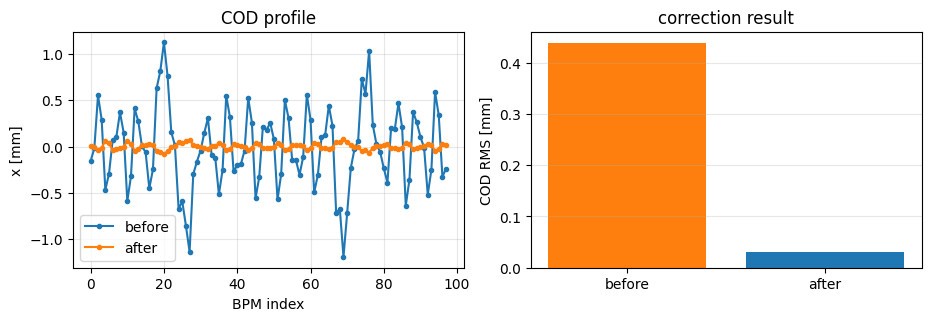

In [3]:
def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2)))


def add_corrector_kick(machine, name, plane, kick_rad):
    # The public correction API uses rad. RFTrack's raw Corrector
    # storage is mrad, so keep the conversion in one tested helper.
    element = machine._single_element(name)
    kick = machine._get_corrector_kick(element)
    kick[plane] += kick_rad
    machine._set_corrector_kick(element, kick)


def bounded_svd_response(matrix, residual, maximum_kick, count=6, rcond=1e-4):
    # Pick phase-distributed useful columns, solve only those columns,
    # then impose a physical corrector limit.
    selected = ATFDRRingCorrection._greedy_columns(matrix, -residual, count, rcond)
    selected_commands, _, rank = ATFDRRingCorrection._svd_solve(
        matrix[:, selected], -residual, rcond
    )
    commands = np.zeros(matrix.shape[1])
    commands[selected] = np.clip(selected_commands, -maximum_kick, maximum_kick)
    return commands, selected, rank


model = ATFDRRingCorrection(load_correction_ring())
virtual_machine = ATFDRRingCorrection(load_correction_ring())

correctors = model.get_corrector_names("x")[:12]
# Hidden fault: it exists only in the virtual machine.
add_corrector_kick(virtual_machine, correctors[0], plane=0, kick_rad=5.0e-5)
before = virtual_machine.find_closed_orbit().x
response = model.compute_orbit_response("x", corrector_names=correctors)
commands, selected, rank = bounded_svd_response(
    response.matrix, before, maximum_kick=2.0e-4
)
for name, command in zip(correctors, commands):
    add_corrector_kick(virtual_machine, name, plane=0, kick_rad=float(command))
after = virtual_machine.find_closed_orbit().x

print(f"SVD rank = {rank}")
print(f"COD RMS: {rms(before):.4e} -> {rms(after):.4e} mm")
figure, axes = plt.subplots(1, 2, figsize=(9.2, 3.1), constrained_layout=True)
axes[0].plot(before, "o-", ms=3, label="before")
axes[0].plot(after, "o-", ms=3, label="after")
axes[0].set(xlabel="BPM index", ylabel="x [mm]", title="COD profile")
axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].bar(("before", "after"), (rms(before), rms(after)), color=("tab:orange", "tab:blue"))
axes[1].set(ylabel="COD RMS [mm]", title="correction result")
axes[1].grid(axis="y", alpha=0.3)


## 3. Dispersion correction

A vertical-steerer fault changes both vertical COD and vertical dispersion.
The stacked response gives dispersion a relative weight of 0.05, as in the SAD-style procedure.


SVD rank = 6
RMS Dy error: 3.4303e+01 -> 4.3036e-01 mm/delta


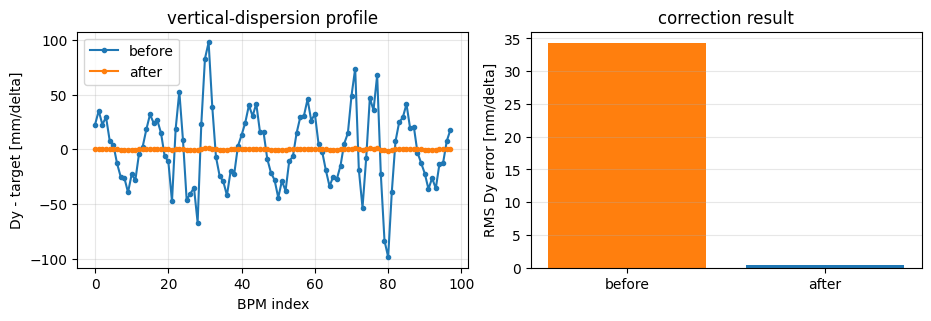

In [4]:
model = ATFDRRingCorrection(load_correction_ring())
virtual_machine = ATFDRRingCorrection(load_correction_ring())
target = model.measure_dispersion(relative_momentum_step=3.5e-3)

correctors = model.get_corrector_names("y")[:8]
# Hidden fault in the virtual machine only.
add_corrector_kick(virtual_machine, correctors[0], plane=1, kick_rad=5.0e-5)

orbit_before = virtual_machine.find_closed_orbit()
dispersion_before = virtual_machine.measure_dispersion(relative_momentum_step=3.5e-3)
response = model.compute_dispersion_response(
    "y", corrector_names=correctors, relative_momentum_step=3.5e-3
)
matrix = np.vstack((0.05 * response.dispersion_matrix, response.orbit_matrix))
residual = np.concatenate((0.05 * (dispersion_before.y - target.y), orbit_before.y))
commands, selected, rank = bounded_svd_response(
    matrix, residual, maximum_kick=2.0e-4
)
for name, command in zip(correctors, commands):
    add_corrector_kick(virtual_machine, name, plane=1, kick_rad=float(command))
dispersion_after = virtual_machine.measure_dispersion(relative_momentum_step=3.5e-3)

print(f"SVD rank = {rank}")
print(f"RMS Dy error: {rms(dispersion_before.y-target.y):.4e} -> {rms(dispersion_after.y-target.y):.4e} mm/delta")
dy_before = dispersion_before.y - target.y
dy_after = dispersion_after.y - target.y
figure, axes = plt.subplots(1, 2, figsize=(9.2, 3.1), constrained_layout=True)
axes[0].plot(dy_before, "o-", ms=3, label="before")
axes[0].plot(dy_after, "o-", ms=3, label="after")
axes[0].set(xlabel="BPM index", ylabel="Dy - target [mm/delta]", title="vertical-dispersion profile")
axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].bar(("before", "after"), (rms(dy_before), rms(dy_after)), color=("tab:orange", "tab:blue"))
axes[1].set(ylabel="RMS Dy error [mm/delta]", title="correction result")
axes[1].grid(axis="y", alpha=0.3)


## 4. Skew correction

Two horizontal correctors are probed. Their vertical BPM responses form the coupling observable.
A skew-quadrupole response matrix proposes compensation without resetting the hidden skew fault.


In [5]:
model = ATFDRRingCorrection(load_correction_ring())
virtual_machine = ATFDRRingCorrection(load_correction_ring())
probes = ("ZH1R", "ZH2R")
available_skews = model.get_skew_corrector_names()
skew_names = tuple(
    available_skews[index]
    for index in np.linspace(0, len(available_skews) - 2, 8, dtype=int)
)
bpm_names = model.bpm_names
response = model.compute_coupling_response(
    probe_corrector_names=probes, skew_corrector_names=skew_names,
    bpm_names=bpm_names, probe_perturbation=1e-5, skew_perturbation=1e-5,
)

hidden_skew = available_skews[-1]
virtual_machine.set_skew_strength(hidden_skew, 1.0e-3)
_, signal_before_2d = virtual_machine._measure_vertical_response_to_horizontal_probes(
    probes, bpm_names=bpm_names, probe_perturbation=1e-5
)
signal_before = signal_before_2d.reshape(-1)
commands, selected, rank = bounded_svd_response(
    response.matrix, signal_before, maximum_kick=2.0e-3, rcond=0.4
)
for name, command in zip(skew_names, commands):
    virtual_machine.set_skew_strength(name, virtual_machine.get_skew_strength(name) + float(command))
_, signal_after_2d = virtual_machine._measure_vertical_response_to_horizontal_probes(
    probes, bpm_names=bpm_names, probe_perturbation=1e-5
)
signal_after = signal_after_2d.reshape(-1)

print(f"SVD rank = {rank}")
print(f"coupling signal RMS: {rms(signal_before):.4e} -> {rms(signal_after):.4e} mm/rad")


SVD rank = 2
coupling signal RMS: 2.6679e+01 -> 1.9467e+00 mm/rad


## 5. Response-mismatch diagnostic

The full procedure is COD → vertical COD + dispersion → skew coupling.
BPM data are residuals in an overdetermined least-squares problem; they are
not extra lattice constraints. The stored 100% Table-I study keeps BPM errors
fixed at 300 um offset and 20 mrad roll.

`nominal` uses a response from the ideal model. `local ORM` measures the
response on the virtual error machine. The latter is a beam-based diagnostic,
not a digital-twin claim.


saved: /home/motokisato/Projects/analysis/DR-RFTrack/kubo2003_100percent_nominal_vs_local_orm.png
nominal model: source=nominal, Dy=30.429 mm/delta, Cxy=0.121, Dy gains=[0.06999999999999999, 0.0]
local ORM: source=local_orm, Dy=3.115 mm/delta, Cxy=0.097, Dy gains=[0.7, 1.0]


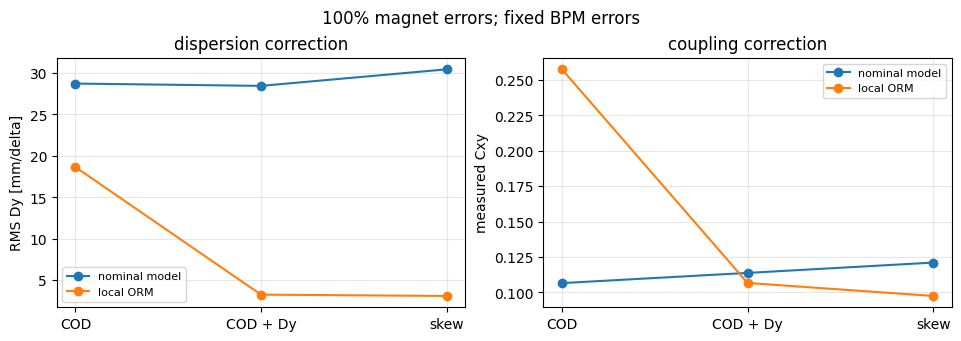

In [6]:
import json

result_paths = {
    "nominal model": ANALYSIS_DIR / (
        "kubo2003_rftrack_procedure_result_20111111b_SF1R_"
        "probe_0p01mrad_solver_sad_greedy_rcond_1em02_seed_2003.json"
    ),
    "local ORM": ANALYSIS_DIR / (
        "kubo2003_rftrack_procedure_result_20111111b_SF1R_"
        "probe_0p01mrad_solver_sad_greedy_response_local_orm_"
        "offset_1_roll_1_rcond_1em02_seed_2003.json"
    ),
}
results = {
    label: json.loads(path.read_text(encoding="utf-8"))
    for label, path in result_paths.items()
    if path.exists()
}
if len(results) != 2:
    raise FileNotFoundError("Run kubo_style_procedure.py for nominal and local_orm first.")

stages = ("after_cod", "after_cod_dispersion", "after_coupling")
stage_labels = ("COD", "COD + Dy", "skew")
metrics = (("true_dy_all_bpm_mm", "RMS Dy [mm/delta]"),
           ("measured_cxy", "measured Cxy"))
figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.3), constrained_layout=True)
for axis, (metric, ylabel) in zip(axes, metrics):
    for label, result in results.items():
        values = [result["stages"][stage][metric] for stage in stages]
        axis.plot(stage_labels, values, "o-", label=label)
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)
axes[0].set_title("dispersion correction")
axes[1].set_title("coupling correction")
figure.suptitle("100% magnet errors; fixed BPM errors")
figure_path = ANALYSIS_DIR / "kubo2003_100percent_nominal_vs_local_orm.png"
figure.savefig(figure_path, dpi=180)
print("saved:", figure_path)

for label, result in results.items():
    settings = result["response_settings"]
    gains = result["cod_dispersion_solver"]["dispersion_applied_gains"]
    final = result["stages"]["after_coupling"]
    source = settings.get("source", "nominal")
    print(f"{label}: source={source}, Dy={final['true_dy_all_bpm_mm']:.3f} mm/delta, "
          f"Cxy={final['measured_cxy']:.3f}, Dy gains={gains}")


## 6. Kubo sequence and equilibrium emittance

This is the validation chain: preliminary orbit → COD → vertical COD +
dispersion → skew coupling. Each stage is evaluated by a full-6D
one-turn radiation map and quantum diffusion, then its equilibrium
covariance is solved. It is not a 10,000-turn particle-tracking result.

The Table-II values are reference points only: this pilot uses the current
2011 daihon, 10% of Table-I magnet errors, and five seeds, whereas the
paper used the historical lattice and a 500-seed ensemble.


pilot seeds: [2003, 2004, 2005, 2006, 2007]
before COD: median vertical-like equilibrium =  24.22 pm rad
       COD: median vertical-like equilibrium =  23.62 pm rad
  COD + Dy: median vertical-like equilibrium =   3.96 pm rad
      skew: median vertical-like equilibrium =   2.84 pm rad


saved: /home/motokisato/Projects/analysis/DR-RFTrack/kubo2003_rftrack_validation_v2_ensemble_summary.png


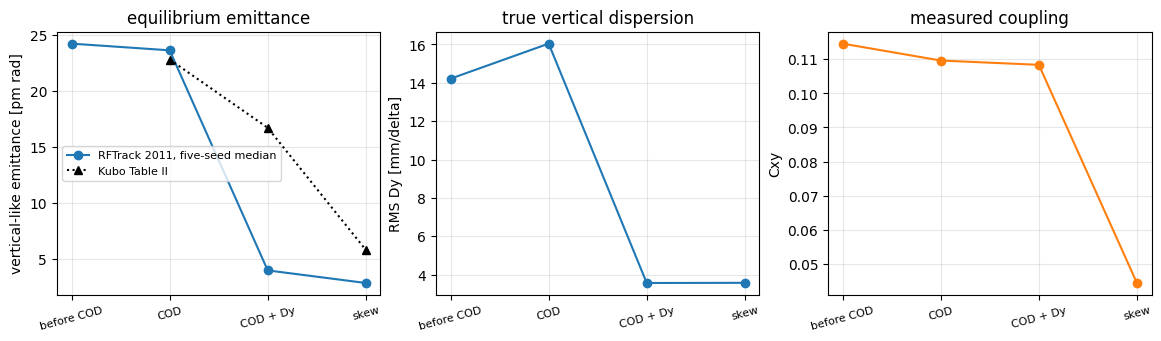

In [7]:
import json

ensemble_path = ANALYSIS_DIR / "kubo2003_rftrack_full6d_v2_scale_0p1_ensemble.json"
kubo_ensemble = json.loads(ensemble_path.read_text(encoding="utf-8"))
labels = ("before COD", "COD", "COD + Dy", "skew")
vertical = kubo_ensemble["vertical_like_eigen_pm_rad"]["median"]
dy = kubo_ensemble["true_dy_rms_mm_per_delta"]["median"]
cxy = kubo_ensemble["measured_cxy"]["median"]
table_ii = np.asarray(
    kubo_ensemble["kubo_table_ii_vertical_emittance_pm_rad"], dtype=float
)

print("pilot seeds:", kubo_ensemble["seeds"])
for stage, value in zip(labels, vertical):
    print(f"{stage:>10s}: median vertical-like equilibrium = {value:6.2f} pm rad")

figure, axes = plt.subplots(1, 3, figsize=(11.5, 3.3), constrained_layout=True)
axes[0].plot(labels, vertical, "o-", label="RFTrack 2011, five-seed median")
axes[0].plot(labels, table_ii, "k^:", label="Kubo Table II")
axes[0].set(ylabel="vertical-like emittance [pm rad]", title="equilibrium emittance")
axes[1].plot(labels, dy, "o-", color="tab:blue")
axes[1].set(ylabel="RMS Dy [mm/delta]", title="true vertical dispersion")
axes[2].plot(labels, cxy, "o-", color="tab:orange")
axes[2].set(ylabel="Cxy", title="measured coupling")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.tick_params(axis="x", rotation=15, labelsize=8)
axes[0].legend(fontsize=8)
figure_path = ANALYSIS_DIR / "kubo2003_rftrack_validation_v2_ensemble_summary.png"
figure.savefig(figure_path, dpi=180)
print("saved:", figure_path)


## 7. What is tracked, and what is optics/envelope calculation?

COD, dispersion, and coupling use repeated **one-turn single-particle**
tracking to find a periodic orbit and finite-difference responses. The
emittance result is different: it is the multi-turn limit of a linearised
radiation map, not a long particle-tracking run.


saved: /home/motokisato/Projects/analysis/DR-RFTrack/atf_dr_rftrack_tracking_and_envelope_flow.png


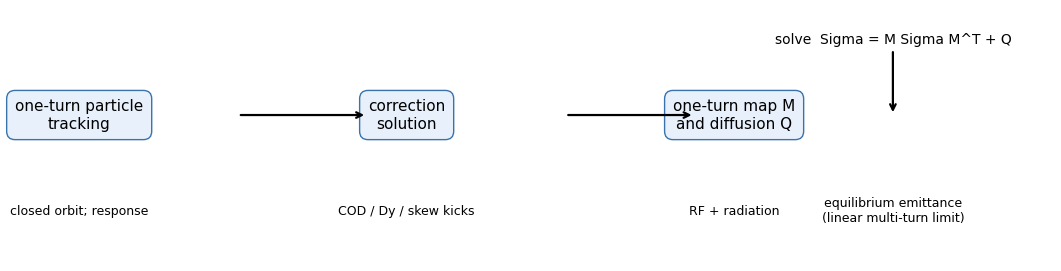

In [8]:
figure, axis = plt.subplots(figsize=(10.5, 2.6), constrained_layout=True)
axis.set_axis_off()

boxes = (
    (0.02, "one-turn particle\ntracking", "closed orbit; response"),
    (0.35, "correction\nsolution", "COD / Dy / skew kicks"),
    (0.68, "one-turn map M\nand diffusion Q", "RF + radiation"),
)
for x, title, subtitle in boxes:
    axis.text(x, 0.58, title, ha="center", va="center", fontsize=11,
              bbox=dict(boxstyle="round,pad=0.55", fc="#e8f1fb", ec="#3973ac"),
              transform=axis.transAxes)
    axis.text(x, 0.20, subtitle, ha="center", va="center", fontsize=9,
              transform=axis.transAxes)
for x in (0.18, 0.51):
    axis.annotate("", xy=(x + 0.13, 0.58), xytext=(x, 0.58),
                  xycoords="axes fraction",
                  arrowprops=dict(arrowstyle="->", lw=1.6))
axis.annotate("solve  Sigma = M Sigma M^T + Q", xy=(0.84, 0.58),
              xytext=(0.84, 0.88), ha="center", va="center",
              xycoords="axes fraction",
              arrowprops=dict(arrowstyle="->", lw=1.6))
axis.text(0.84, 0.20, "equilibrium emittance\n(linear multi-turn limit)",
          ha="center", va="center", fontsize=9, transform=axis.transAxes)
figure_path = ANALYSIS_DIR / "atf_dr_rftrack_tracking_and_envelope_flow.png"
figure.savefig(figure_path, dpi=180)
print("saved:", figure_path)


## 8. Full-6D equilibrium from one-turn maps

RFTrack supplies a deterministic radiation/RF map \(M\) by finite
differences about the synchronous orbit. A 64-particle **one-turn**
quantum-radiation run supplies \(Q\). The discrete Lyapunov equation
\(\Sigma=M\Sigma M^T+Q\) gives the stationary covariance directly.

This is valid only when the full-6D spectral radius is below one.


spectral radius = 0.999986120  (< 1 means damping is stable)
1/e damping time = 72046 turns
vertical-like, horizontal-like eigen emittance [pm rad] = [5.52509832e-32 4.24053487e+02]
projected x, y emittance [pm rad] = 424.0534869267956 7.373194800722727e-32
saved: /home/motokisato/Projects/analysis/DR-RFTrack/atf_dr_rftrack_one_turn_map_spectrum.png


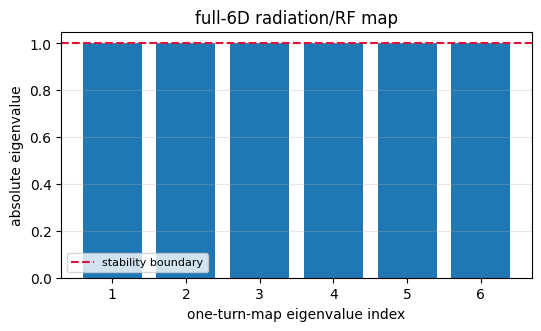

In [9]:
deterministic_lattice = build_equilibrium_lattice(quantum=False)
quantum_lattice = build_equilibrium_lattice(quantum=True)
equilibrium = equilibrium_emittance_for_lattices(
    deterministic_lattice, quantum_lattice, quantum_particles=64
)

print(f"spectral radius = {equilibrium.spectral_radius:.9f}  (< 1 means damping is stable)")
print(f"1/e damping time = {equilibrium.damping_turns_one_over_e:.0f} turns")
print("vertical-like, horizontal-like eigen emittance [pm rad] =", np.asarray(equilibrium.eigen_emittances_m_rad) * 1e12)
print("projected x, y emittance [pm rad] =", equilibrium.projected_x_m_rad * 1e12, equilibrium.projected_y_m_rad * 1e12)

map_eigenvalues = np.linalg.eigvals(equilibrium.one_turn_map)
figure, axis = plt.subplots(figsize=(5.3, 3.2), constrained_layout=True)
axis.bar(np.arange(1, 7), np.abs(map_eigenvalues), color="tab:blue")
axis.axhline(1.0, color="crimson", ls="--", label="stability boundary")
axis.set(xlabel="one-turn-map eigenvalue index", ylabel="absolute eigenvalue",
         title="full-6D radiation/RF map")
axis.set_ylim(0, max(1.05, 1.03 * np.max(np.abs(map_eigenvalues))))
axis.grid(axis="y", alpha=0.3); axis.legend(fontsize=8)
figure_path = ANALYSIS_DIR / "atf_dr_rftrack_one_turn_map_spectrum.png"
figure.savefig(figure_path, dpi=180)
print("saved:", figure_path)


## 9. 10,000-turn covariance propagation

This propagates a covariance with the map, not 64 particles through
10,000 RFTrack turns. The blue curve is damping only; the orange curve
adds \(Q\) each turn and approaches the equilibrium in section 8.


map-propagated turns = 10000; seed particles = 64 (not tracked)
1/e damping time = 72046 turns


saved: /home/motokisato/Projects/analysis/DR-RFTrack/atf_dr_rftrack_10000_turn_damping.png


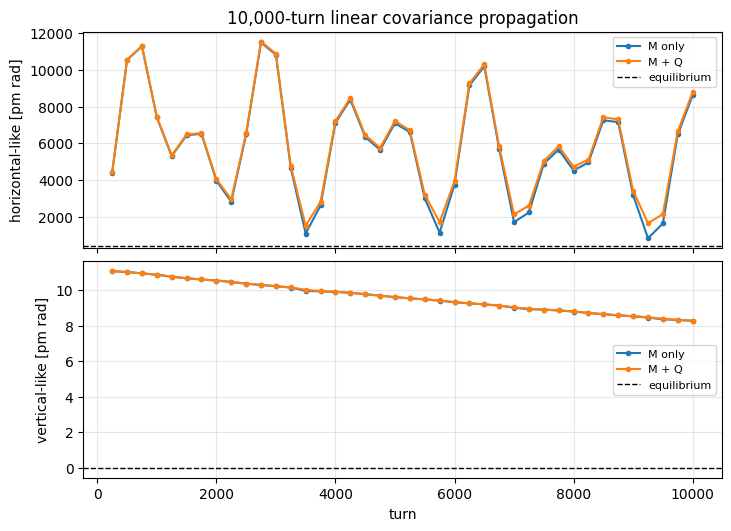

In [10]:
TRACKED_TURNS = 10_000
TRACKED_PARTICLES = 64

# Start above the equilibrium emittance to make damping visible.
initial_bunch = gaussian_bunch(
    equilibrium.synchronous_orbit,
    particles=TRACKED_PARTICLES,
    emit_x_m_rad=1.0e-9,
    emit_y_m_rad=1.0e-11,
    beta_x_m=5.0,
    beta_y_m=5.0,
    sigma_delta=1.0e-3,
    sigma_ct_mm=1.0,
    seed=20260916,
)

covariance_native = np.cov(
    initial_bunch.get_phase_space(), rowvar=False, ddof=1
)
damping_covariance = covariance_native.copy()
radiation_covariance = covariance_native.copy()
damping_samples = []
radiation_samples = []
for turn in range(1, TRACKED_TURNS + 1):
    damping_covariance = (
        equilibrium.one_turn_map @ damping_covariance
        @ equilibrium.one_turn_map.T
    )
    radiation_covariance = (
        equilibrium.one_turn_map @ radiation_covariance
        @ equilibrium.one_turn_map.T + equilibrium.diffusion_native
    )
    if turn % 250 == 0 or turn == TRACKED_TURNS:
        damping_samples.append(
            emittance_from_native_covariance(damping_covariance, turns=turn)
        )
        radiation_samples.append(
            emittance_from_native_covariance(radiation_covariance, turns=turn)
        )

sample_turns = [sample.turns for sample in radiation_samples]
damping_vertical_pm = [sample.eigen_emittances_m_rad[0] * 1e12 for sample in damping_samples]
radiation_vertical_pm = [sample.eigen_emittances_m_rad[0] * 1e12 for sample in radiation_samples]
damping_horizontal_pm = [sample.eigen_emittances_m_rad[1] * 1e12 for sample in damping_samples]
radiation_horizontal_pm = [sample.eigen_emittances_m_rad[1] * 1e12 for sample in radiation_samples]
print(f"map-propagated turns = {TRACKED_TURNS}; seed particles = {TRACKED_PARTICLES} (not tracked)")
print(f"1/e damping time = {equilibrium.damping_turns_one_over_e:.0f} turns")

figure, axes = plt.subplots(2, 1, figsize=(7.2, 5.2), sharex=True, constrained_layout=True)
axes[0].plot(sample_turns, damping_horizontal_pm, "o-", ms=3, label="M only")
axes[0].plot(sample_turns, radiation_horizontal_pm, "o-", ms=3, color="tab:orange", label="M + Q")
axes[0].axhline(equilibrium.eigen_emittances_m_rad[1] * 1e12, color="k", ls="--", lw=1, label="equilibrium")
axes[0].set(ylabel="horizontal-like [pm rad]", title="10,000-turn linear covariance propagation")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].plot(sample_turns, damping_vertical_pm, "o-", ms=3, label="M only")
axes[1].plot(sample_turns, radiation_vertical_pm, "o-", ms=3, color="tab:orange", label="M + Q")
axes[1].axhline(equilibrium.eigen_emittances_m_rad[0] * 1e12, color="k", ls="--", lw=1, label="equilibrium")
axes[1].set(xlabel="turn", ylabel="vertical-like [pm rad]")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
figure_path = ANALYSIS_DIR / "atf_dr_rftrack_10000_turn_damping.png"
figure.savefig(figure_path, dpi=180)
print("saved:", figure_path)


## 10. Optional direct multi-particle tracking

This is the nonlinear validation path. It tracks a quantum-radiation
bunch turn by turn, so it is much slower than sections 8--9. Keep it
disabled for the standard educational run; enable it only for a chosen
stable lattice and a modest turn count.


In [11]:
RUN_PARTICLE_TRACKING = False
DIRECT_TRACKING_TURNS = 1_000

if RUN_PARTICLE_TRACKING:
    direct_lattice = build_equilibrium_lattice(quantum=True)
    direct_bunch = gaussian_bunch(
        equilibrium.synchronous_orbit, particles=256,
        emit_x_m_rad=1.0e-9, emit_y_m_rad=1.0e-11,
        beta_x_m=5.0, beta_y_m=5.0, sigma_delta=1.0e-3,
        sigma_ct_mm=1.0, seed=20260916,
    )
    _, direct_samples = track_emittance(
        direct_lattice, direct_bunch, turns=DIRECT_TRACKING_TURNS,
        sample_every=100,
    )
    direct_turns = [sample.turns for sample in direct_samples]
    direct_vertical = [sample.eigen_emittances_m_rad[0] * 1e12 for sample in direct_samples]
    figure, axis = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
    axis.plot(direct_turns, direct_vertical, "o-", label="direct particle tracking")
    axis.axhline(equilibrium.eigen_emittances_m_rad[0] * 1e12, color="k", ls="--", label="linear equilibrium")
    axis.set(xlabel="turn", ylabel="vertical-like [pm rad]")
    axis.grid(alpha=0.3); axis.legend(fontsize=8)
    figure_path = ANALYSIS_DIR / "atf_dr_rftrack_direct_tracking.png"
    figure.savefig(figure_path, dpi=180)
    print("saved:", figure_path)
else:
    print("Direct particle tracking is disabled; set RUN_PARTICLE_TRACKING = True to run it.")


Direct particle tracking is disabled; set RUN_PARTICLE_TRACKING = True to run it.


## 11. State-synchronised response

SAD loads known magnet and corrector values before calculating a model
response. RFTrack can use the same separation: the snapshot supplies
strengths, kicks, and skew settings; unknown alignment errors remain
model mismatch.


In [12]:
STATE_SNAPSHOT = ANALYSIS_DIR / "atf_dr_20111111b_known_machine_state_nominal.json"
state = read_known_machine_state(STATE_SNAPSHOT)
state_model_lattice = build_atf_dr_lattice()
apply_known_machine_state(state_model_lattice, state)
state_model = ATFDRRingCorrection(state_model_lattice)

print("snapshot:", STATE_SNAPSHOT.name)
print("normal magnets:", len(state["normal_magnets"]))
print("correctors:", len(state["correctors"]))
print("skew correctors:", len(state["skew_correctors"]))
print("BPMs in response fit:", len(state_model.bpm_names))


snapshot: atf_dr_20111111b_known_machine_state_nominal.json
normal magnets: 204
correctors: 101
skew correctors: 68
BPMs in response fit: 98


## Scope

This validates the RFTrack correction workflow and shows why a local ORM
can recover a large-error case. It does not reproduce Kubo Table II yet:
the present lattice is the 2011 daihon, not the original 2003 machine.
A Table-II claim requires a matched lattice, error model, radiation model,
and a seed ensemble.
